# Hotel Booking Cancellation Prediction

**Introduction / Problem Overview¶****
Hotel booking cancellations create important challenges for hotel management because they affect occupancy planning, staffing, revenue stability, and overbooking decisions. When many reservations are canceled, hotels may lose revenue and face difficulty using rooms efficiently.

This project applies supervised machine learning classification methods to predict whether a booking will be canceled. The goal is to compare different models, evaluate their performance, and identify the algorithm that best supports practical business decision-making.

**Dataset Description**
This project uses the Hotel Booking Demand dataset, which contains hotel reservation records for City Hotel and Resort Hotel bookings. Each row represents one booking, and the target variable, is_canceled, indicates whether the reservation was canceled (1) or not (0).

The dataset includes a mixture of customer, reservation, and service-related information such as:

1. booking lead time
2. meal type
3. market segment
4. distribution channel
5. average daily rate (ADR)
6. number of special requests
7. customer type
8. room assignment details
* This dataset is suitable for a binary classification task because the main objective is to predict a yes/no outcome from multiple features.

# Project Objective
The objective of this project is to build and compare several supervised machine learning classification models to predict whether a hotel booking will be canceled.

More specifically, this analysis aims to:

* preprocess and clean the booking data
* explore variables related to cancellation behavior
* train and evaluate multiple classification models
* compare results using appropriate evaluation metrics
* select the model that best satisfies the project goal
* The final outcome is a model and interpretation that can help hotels better understand cancellation patterns and support decisions that reduce revenue loss.

# Data Cleaning and Preprocessing
Before modeling, the dataset was cleaned and prepared carefully:

* duplicate rows were removed
* columns with strong leakage or too many missing values were dropped
* missing values in selected columns were filled using suitable methods
* categorical variables were encoded
* numerical features were scaled when needed for specific models
These preprocessing steps improved the quality of the dataset and made the model comparison more reliable.

# Code Documentation Notes
The code cells below include inline comments using # so each step of the workflow is easy to follow.
These comments explain the purpose of the code for data cleaning, exploratory data analysis, preprocessing, modeling, evaluation, and final comparison.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix,classification_report, precision_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [72]:
import pandas as pd
#reading the hotel demand datset downloaded from Kaggle
df = pd.read_csv('/content/hotel_bookings.csv')

In [73]:
#UNDERSTANDING THE DATA
df.head()
#resulting first five rows in the data set

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [74]:
df.info()
#The data set consists of 32 columns on a whole

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# Data types:

* Categorical - hotel, is_canceled, customer_type, is_repeated_guest, meal, country, market_segment, distribution_channel, reserved_room_type, assigned_room_type, deposit_type, agent, company, reservation_status,
* Numerical - lead_time, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, previous_cancellations, booking_changes, previous_bookings_not_canceled, days_in_waiting_list, adr, required_car_parking_spaces, total_of_special_requests
* Ordinal - arrival_date_year, arrival_date_month, arrival_date_week_number, arrival_date_day_of_month, reservation_status_date

# Mising values:
1. childern
1. country
1. agent
1. company

In [75]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [76]:
df.isna().sum()

#The above command gives an integer value of all the missing values in each column
#There are two ways to handle missing values - Deleting or Imputing the missing values
#Deleting is a bad approach as it may affect other features.
#Children, Country, Agent and Company are the features which has missing values.

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


**** fillna column childern

In [77]:
df['children'].mean()

#To replace the missing values in Children column, trying to find mean, median and mode to check which is better.
#mean value is a floating point value but children can never be float
#So not using the mean value to replace missing values.

np.float64(0.10388990333874994)

In [78]:
df['children'].median()
df['children'].mode()

#Mode and median are same which is 0. To check with which to replace with, using one more method below

,children
0,0.0


In [79]:
df['children'].value_counts()

#value_counts method returns the most frequent value in that column and the count of it
#respectively for all values in that column.
#For children 0 is the most frequest value which is mode and median.
#So, replacing the missing values of children with 0

,count
children,
0.0,110796
1.0,4861
2.0,3652
3.0,76
10.0,1


In [80]:
df['children'] = df['children'].fillna(0)

**fillna column country**

In [81]:
df['country'].value_counts()

#Imputing the missing values in column country with most frequest country.

,count
country,
PRT,48590
GBR,12129
FRA,10415
ESP,8568
DEU,7287
...,...
MRT,1
KIR,1
SDN,1


In [82]:
df['country'] = df['country'].fillna(df['country'].value_counts().index[0])

In [83]:
df =df.drop(columns = ['agent', 'company'])

#Company column has more than 90% of missing values, so dropping it as it is not needed
#In the agent column the most frequent value is very less but the actual missing values are much high.
#Imputing with mode will not be optimal and as most of the values are NaN, we can impute 0 or drop the agent column

In [84]:
df.isna().sum()

#Below is the missing values after handling all the columns

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


**duplicates **

In [85]:
df.duplicated().any()
#To check if there are any duplicate values in rows of the data set

np.True_

In [86]:
df.duplicated().sum()
#To result the number of rows which has duplicate values

np.int64(32039)

In [87]:
df.drop_duplicates(inplace=False)

#Using pandas built-in method to drop duplicate rows
#By default, this method returns new DataFrame with duplicate rows removed
#We can set the argument(inplace = true) to remove duplicates from original DataFrame.

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07


**outlier**

In [88]:
df['adr'].unique()

array([  0.  ,  75.  ,  98.  , ..., 266.75, 209.25, 157.71])

In [89]:
df.describe()

#Checking for outliers
#Outlier is  value that lies in an abnormal distance from other values.
#If we observe the mean and min or max values of all columns, adr column has a negative value, and the minimum value is
#extremely far from mean value, which means the minimum value is an outlier.

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


<Axes: xlabel='adr'>

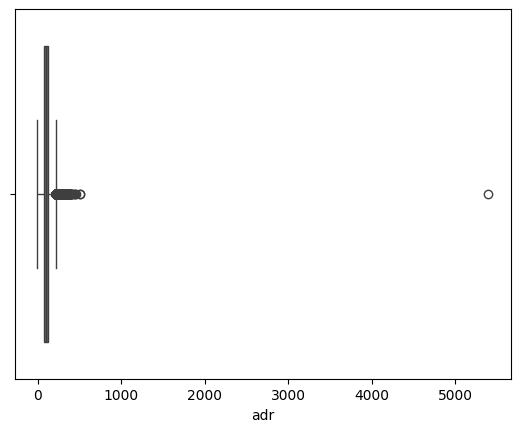

In [90]:
sns.boxplot(x=df['adr'])

#We can visualize outliers using boxplot

In [91]:
df[df['adr'] <0]
#Resulting any value of adr column which has negative values

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [92]:
df = df.drop(df[df.adr < 0].index)
df[df['adr'] < 0]
#Dropping the negative value row and printing to check if there are any more negative values
#We get 0 rows that means no more negative values.

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [93]:
df[df['adr']> 5000]

#If we observe the boxplot above, there is only one value above 5000 which is at extreme compared to others

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [94]:
df = df.drop(df[df.adr > 5000].index)
df[df['adr']> 5000]

#Dropping the row with 5000

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [95]:
df[df['adults']+df['babies']+df['children'] == 0].shape

#There are some rows which has adults,babies,children equal to 0.
#No booking cab be made with adult/children 0. So, check if there are any rows of the above kind.
#There are 180 rows of suck kind, Our algorithm will not learn anything from these rows.
#Dropping all the rows which satisfy above conditiondf1.

(180, 30)

In [96]:
df.drop(df[df['adults']+df['babies']+df['children'] == 0].index, inplace = True)

# Exploratory Data Analysis
Before training the models, exploratory data analysis was performed to understand how booking features relate to cancellation behavior. The following charts and pairplots highlight patterns that may be useful for classification, such as lead time, deposit type, market segment, customer behavior, and service requests.

In [97]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75010
1,44198


<Axes: xlabel='is_canceled'>

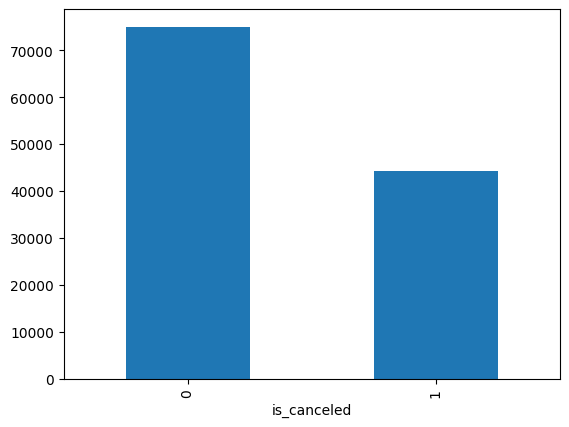

In [98]:
df['is_canceled'].value_counts().plot(kind = 'bar')

#If we look at the bar plot of target variable there is approximately 2:1 ratio between majority and minority class.

* When the data is imbalanced there is a chance that the model will be biased towards majority class.
* Synthetic Minority Oversampling Technique or SMOTE is another technique to oversample the minority class.
* Simply adding duplicate records of minority class often don’t add any new information to the model.
* In SMOTE new instances are synthesized from the existing data. If we explain it in simple words, SMOTE looks into
* minority class instances and use k nearest neighbor to select a random nearest neighbor, and a synthetic instance is
* created randomly in feature space.
* We still haven't balanced the data set as SMOTE tends to create a large no. of noisy data points in feature space.

**Feature Engineering**

In [99]:
df['total_people'] = df['adults'] + df['babies'] + df['children']
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

#Adding two new columns
#Combining adults, babies,children into total_people
#Similarly added total_stay column

Text(0.5, 1.0, 'Pie Chart for Most Preffered  Hotel')

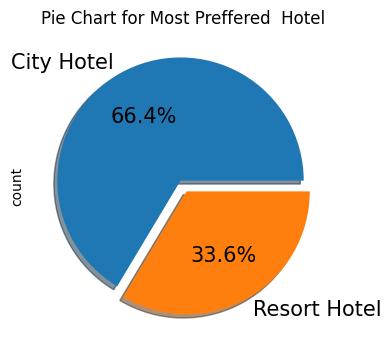

In [100]:
#Data Visualization

df['hotel'].value_counts().plot.pie(explode=[0.05, 0.05], autopct='%1.1f%%',shadow=True,  figsize=(6,4),fontsize=15)
plt.title('Pie Chart for Most Preffered  Hotel')

#Pie chart to visualize the ratio between Resort hotel and City hotel

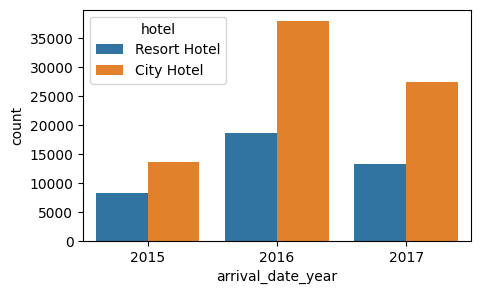

In [101]:
plt.subplots(figsize=(5, 3))
sns.countplot(x='arrival_date_year', hue='hotel',  data=df);

#The percetage of booking each year?
#More than double bookings were made in the year 2016 than previous year

Text(0, 0.5, 'Number of bookings')

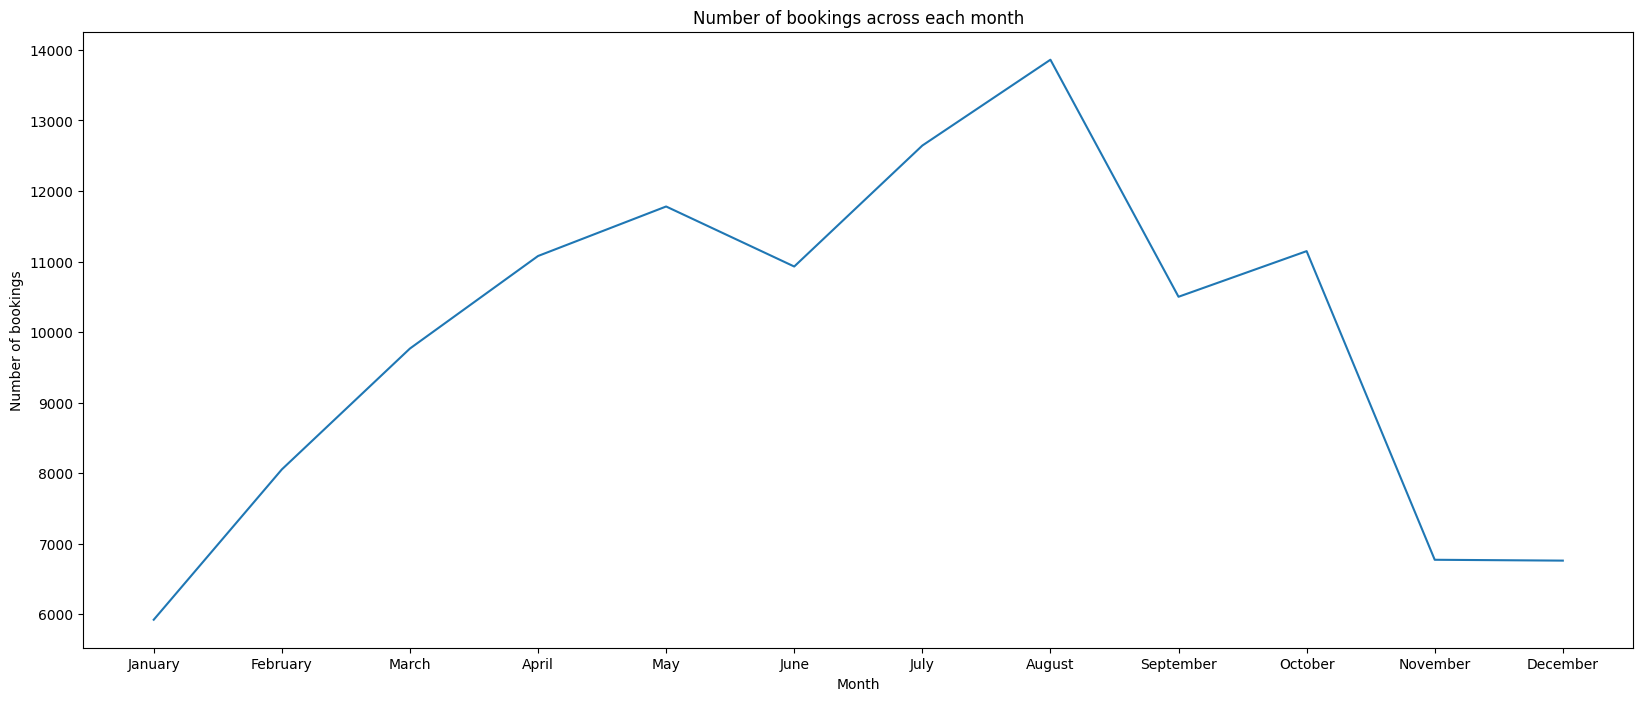

In [102]:
#In which month most bookings happened?

# groupby arrival_date_month and taking the hotel count
bookings_by_months_df=df.groupby(['arrival_date_month'])['hotel'].count().reset_index().rename(columns={'hotel':"Counts"})
# Create list of months in order
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
# creating df which will map the order of above months list without changing its values.
bookings_by_months_df['arrival_date_month']=pd.Categorical(bookings_by_months_df['arrival_date_month'],categories=months,ordered=True)
# sorting by arrival_date_month
bookings_by_months_df=bookings_by_months_df.sort_values('arrival_date_month')

bookings_by_months_df

plt.figure(figsize=(20,8))

#pltting lineplot on x- months & y- booking counts
sns.lineplot(x=bookings_by_months_df['arrival_date_month'],y=bookings_by_months_df['Counts'])

# set title for the plot
plt.title('Number of bookings across each month')
#set x label
plt.xlabel('Month')
#set y label
plt.ylabel('Number of bookings')

<Axes: title={'center': 'Avg ADR of each Hotel type'}, xlabel='Hotel type', ylabel='ADR'>

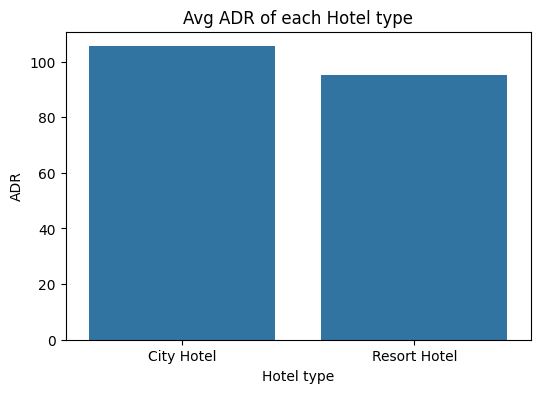

In [103]:
#BIVARIATE AND MULTIVARIATE ANALYSIS

#Which hotel type has the highest ADR

#grouping by hotel adr
grup_by_hotel=df.groupby('hotel')

highest_adr=grup_by_hotel['adr'].mean().reset_index()

#set plot size
plt.figure(figsize=(6,4))

# set labels
plt.xlabel('Hotel type')
plt.ylabel('ADR')
plt.title("Avg ADR of each Hotel type")

#plot the graph
sns.barplot(x=highest_adr['hotel'],y=highest_adr['adr'])

#City Hotel has the highest ADR that means city hotels are generating more revenue than resort hotels

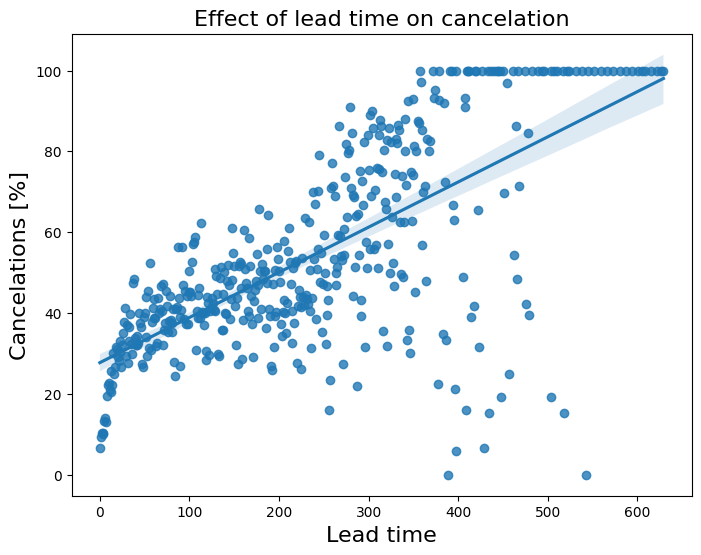

In [104]:
#Effect of lead_time on cancellation using scatter plot


# group data for lead_time:
lead_cancel_data = df.groupby("lead_time")["is_canceled"].describe()
# use only lead_times wih more than 10 bookings for graph:
lead_cancel_data_10 = lead_cancel_data.loc[lead_cancel_data["count"] >= 10]

#show figure:
plt.figure(figsize=(8, 6))
sns.regplot(x=lead_cancel_data_10.index, y=lead_cancel_data_10["mean"].values * 100)
plt.title("Effect of lead time on cancelation", fontsize=16)
plt.xlabel("Lead time", fontsize=16)
plt.ylabel("Cancelations [%]", fontsize=16)
# plt.xlim(0,365)
plt.show()

#Bookings made few days before are rarely canceled, whereas bookings made one year in advance are canceled very often

**Correlation Matrix of the Hotel Booking**

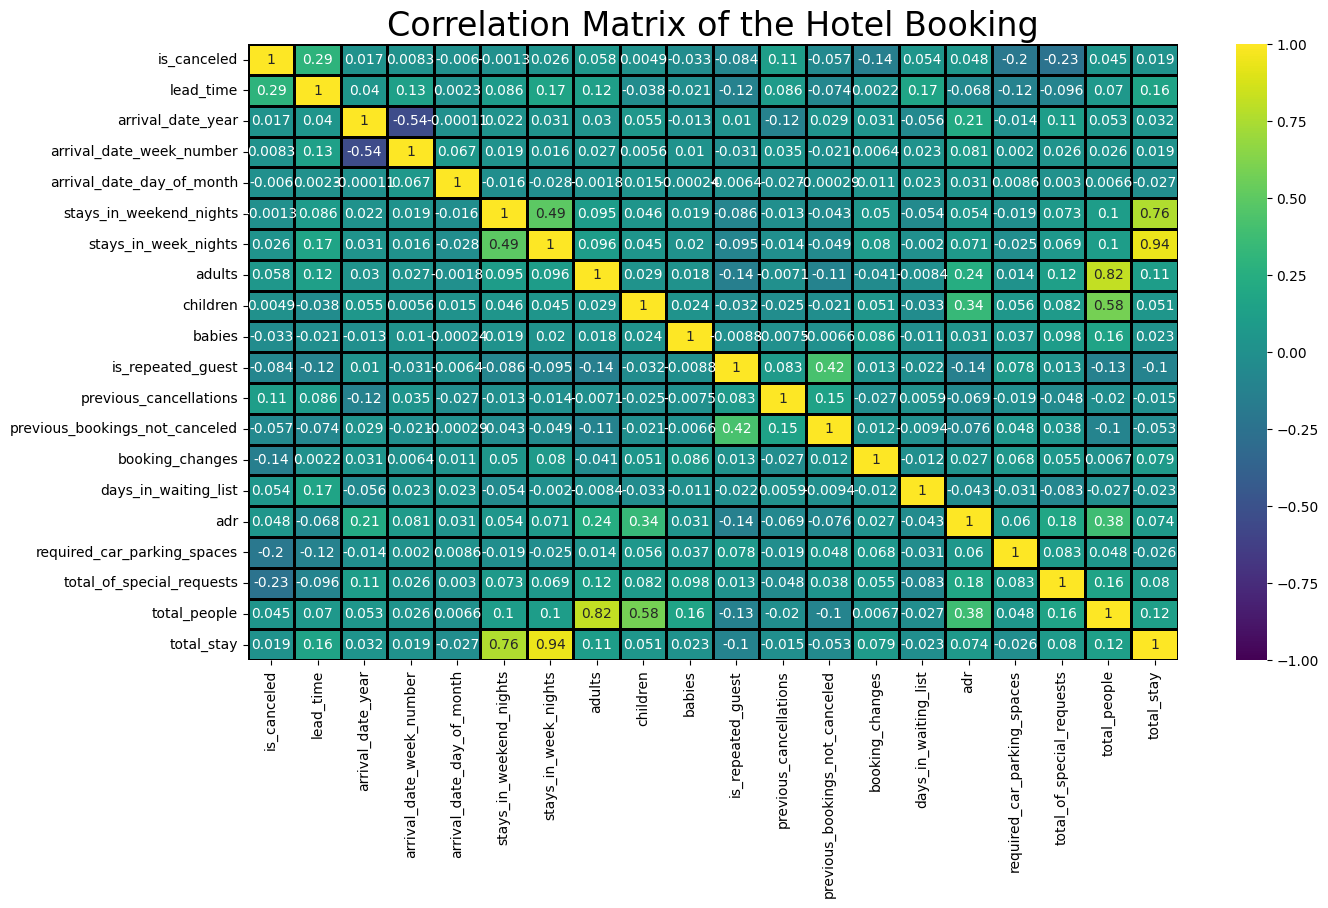

In [105]:
hotel_booking_df = df.copy()

numeric_df = hotel_booking_df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 8))
sns.heatmap(numeric_df.corr(),
            vmin=-1, vmax=1,
            annot=True,
            linewidths=1,
            linecolor='black',
            cmap="viridis")

plt.title('Correlation Matrix of the Hotel Booking', fontsize=24)
plt.show()

# Encoding categorical variables

In [106]:
df_le = df.copy()

In [107]:
lb = LabelEncoder()
# List all categorical columns that need to be encoded
categorical_cols_to_encode = [
    'hotel', 'customer_type', 'market_segment', 'distribution_channel',
    'deposit_type', 'reserved_room_type', 'arrival_date_month', 'country',
    'meal', 'assigned_room_type', 'reservation_status', 'reservation_status_date'
]
for col in categorical_cols_to_encode:
    # Ensure the column exists before trying to encode it
    if col in df_le.columns:
        df_le[col] = lb.fit_transform(df_le[col])

In [108]:
data = pd.get_dummies(df_le, columns=['hotel', 'customer_type', 'market_segment', 'distribution_channel'])

In [109]:
df_le

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_people,total_stay
0,1,0,342,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,3,0,0,2,0.00,0,0,1,121,2.0,0
1,1,0,737,2015,5,27,1,0,0,2,0.0,0,0,135,3,1,0,0,0,2,2,4,0,0,2,0.00,0,0,1,121,2.0,0
2,1,0,7,2015,5,27,1,0,1,1,0.0,0,0,59,3,1,0,0,0,0,2,0,0,0,2,75.00,0,0,1,122,1.0,1
3,1,0,13,2015,5,27,1,0,1,1,0.0,0,0,59,2,0,0,0,0,0,0,0,0,0,2,75.00,0,0,1,122,1.0,1
4,1,0,14,2015,5,27,1,0,2,2,0.0,0,0,59,6,3,0,0,0,0,0,0,0,0,2,98.00,0,1,1,123,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0,0,23,2017,1,35,30,2,5,2,0.0,0,0,15,5,3,0,0,0,0,0,0,0,0,2,96.14,0,0,1,919,2.0,7
119386,0,0,102,2017,1,35,31,2,5,3,0.0,0,0,56,6,3,0,0,0,4,4,0,0,0,2,225.43,0,2,1,920,3.0,7
119387,0,0,34,2017,1,35,31,2,5,2,0.0,0,0,43,6,3,0,0,0,3,3,0,0,0,2,157.71,0,4,1,920,2.0,7
119388,0,0,109,2017,1,35,31,2,5,2,0.0,0,0,59,6,3,0,0,0,0,0,0,0,0,2,104.40,0,0,1,920,2.0,7


In [110]:
df_le.corr()['is_canceled'].abs().sort_values(ascending=False)[1:]

,is_canceled
reservation_status,0.917175
deposit_type,0.468663
lead_time,0.292892
country,0.268046
total_of_special_requests,0.234877
required_car_parking_spaces,0.195702
assigned_room_type,0.175825
distribution_channel,0.167695
reservation_status_date,0.162167
booking_changes,0.144834


In [111]:
# since we have columns that that's have almost similar value like children babies, now is combined into total_people
# stays in weekend nights and stays in week nights now combined into total stays. So, we will be dropping both columns.
# Furthermore, in the above matrix, there appears to be a negative high correlation between reservation_status
# and is_canceled features.
# also dropping the reservation_status_date column because it is related to the reservation_status column.

df_le = df_le.drop(columns=[
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'babies',
    'children',
    'days_in_waiting_list',
    'arrival_date_year',
    'assigned_room_type',
    'meal',
    'reserved_room_type',
    'reservation_status',
    'reservation_status_date',
    'agent', # Dropping agent column due to NaNs
    'company' # Dropping company column due to NaNs
], errors='ignore')

df_le = df_le.reset_index(drop=True)
df_le.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,adults,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_people,total_stay
0,1,0,342,5,27,1,2,135,3,1,0,0,0,3,0,2,0.0,0,0,2.0,0
1,1,0,737,5,27,1,2,135,3,1,0,0,0,4,0,2,0.0,0,0,2.0,0
2,1,0,7,5,27,1,1,59,3,1,0,0,0,0,0,2,75.0,0,0,1.0,1
3,1,0,13,5,27,1,1,59,2,0,0,0,0,0,0,2,75.0,0,0,1.0,1
4,1,0,14,5,27,1,2,59,6,3,0,0,0,0,0,2,98.0,0,1,2.0,2


In [112]:
X = df_le.drop('is_canceled', axis=1)
y = df_le['is_canceled']

# split data

In [113]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                # Features and target variable
    test_size=0.2,       # 20% of data used for testing
    random_state=42,     # Ensures reproducibility
    stratify=y           # Keeps class distribution balanced
)
# Display shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (95366, 20)
Testing data shape: (23842, 20)


**scaling**

In [114]:
from sklearn.preprocessing import RobustScaler

# Initialize scaler
scaler = RobustScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [115]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# bulid model before feature selection

**LogisticRegression**

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_model = LogisticRegression(C=1, solver='liblinear', max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Accuracy: 0.7920057042194447
Precision: 0.8217542696070304
Recall: 0.5606334841628959
F1: 0.6665321767197901
Confusion Matrix:
 [[13927  1075]
 [ 3884  4956]]


**Decision Tree**

In [117]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)

print("Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1:", f1_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Tree Accuracy: 0.7900763358778626
Precision: 0.8300912377345498
Recall: 0.5454751131221719
F1: 0.6583384531367329
Confusion Matrix:
 [[14015   987]
 [ 4018  4822]]


**Random Forest**

In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.8813857897827363
Precision: 0.8727678571428571
Recall: 0.7961538461538461
F1: 0.8327023189777567
Confusion Matrix:
 [[13976  1026]
 [ 1802  7038]]


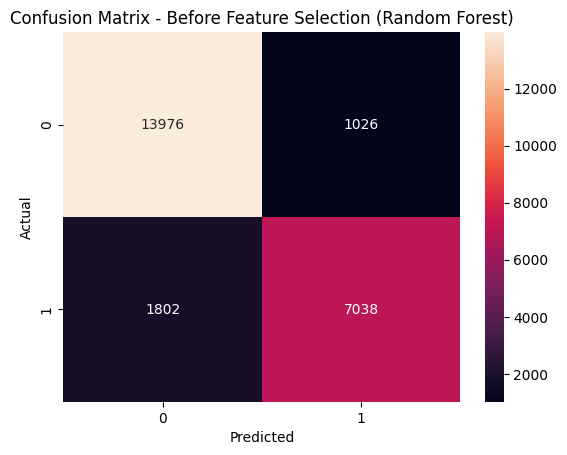

In [119]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Before Feature Selection (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Diagram (Before Feature Selection Accuracy**

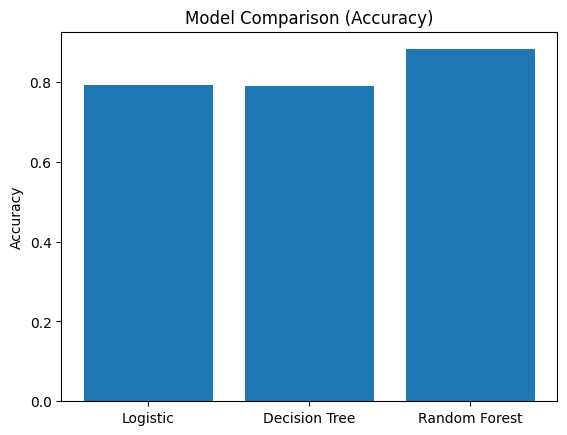

In [120]:
models = ['Logistic', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies)
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

#  feature selection

In [121]:
from sklearn.feature_selection import SelectKBest, f_classif

# ==============================
# Hyperparameters:
# k = number of selected features
# score_func = statistical method to rank features
# ==============================

selector = SelectKBest(
    score_func=f_classif,  # ANOVA test (for classification)
    k=8                    # number of best features to keep
)

# Fit ONLY on training data (important to avoid data leakage)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# Transform test data using same selection
X_test_selected = selector.transform(X_test_scaled)

In [122]:
# Get selected feature names after SelectKBest
selected_features = X_train.columns[selector.get_support()]

# Print selected features
print("Selected Features:")
print(selected_features)

# Optional: show feature scores
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
})

# Sort by highest score
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print("\nFeature Scores:")
print(feature_scores)

# Display top selected features only
print("\nTop Selected Features:")
print(feature_scores.head(8))

Selected Features:
Index(['hotel', 'lead_time', 'country', 'distribution_channel',
       'booking_changes', 'deposit_type', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

Feature Scores:
                           Feature         Score
13                    deposit_type  26789.492528
1                        lead_time   8931.831103
6                          country   7419.683273
17       total_of_special_requests   5638.945283
16     required_car_parking_spaces   3797.000257
8             distribution_channel   2706.270886
12                 booking_changes   2022.228226
0                            hotel   1716.026261
10          previous_cancellations   1168.537559
9                is_repeated_guest    683.728093
14                   customer_type    471.670908
7                   market_segment    328.841841
5                           adults    327.566876
11  previous_bookings_not_canceled    313.757682
15                             ad

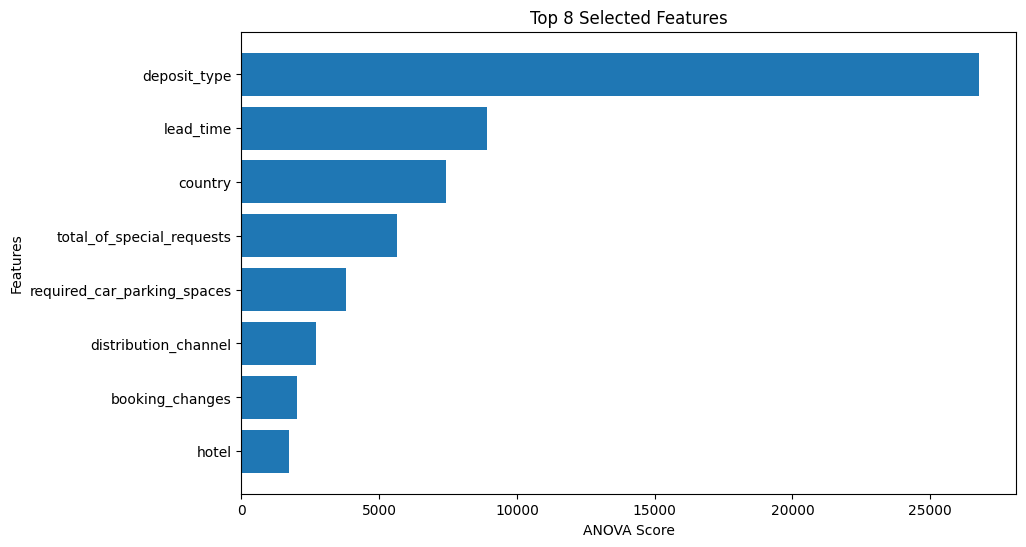

In [123]:
import matplotlib.pyplot as plt

top_features = feature_scores.head(8)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Score'])
plt.xlabel("ANOVA Score") #Analysis of Variance
plt.ylabel("Features")
plt.title("Top 8 Selected Features")
plt.gca().invert_yaxis()
plt.show()

# model after feature selection

**LogisticRegression**

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize model
log_model = LogisticRegression(
    C=1,
    solver='liblinear',
    max_iter=1000
)

# Train
log_model.fit(X_train_selected, y_train)

# Predict
y_pred_log = log_model.predict(X_test_selected)

# Metrics
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Accuracy: 0.764407348376814
Precision: 0.8277404921700223
Recall: 0.4604072398190045
F1 Score: 0.5916987715344916
Confusion Matrix:
 [[14155   847]
 [ 4770  4070]]


**DecisionTree**

In [125]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train_selected, y_train)
y_pred_tree = tree_model.predict(X_test_selected)

print("Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Tree Accuracy: 0.7745994463551715
Precision: 0.7494961128707169
Recall: 0.5889140271493213
F1 Score: 0.6595717724566071
Confusion Matrix:
 [[13262  1740]
 [ 3634  5206]]


**RandomForest**

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_selected, y_train)
y_pred_rf = rf_model.predict(X_test_selected)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.8089505913933395
Precision: 0.7715806819622258
Recall: 0.6885746606334842
F1 Score: 0.7277183334329608
Confusion Matrix:
 [[13200  1802]
 [ 2753  6087]]


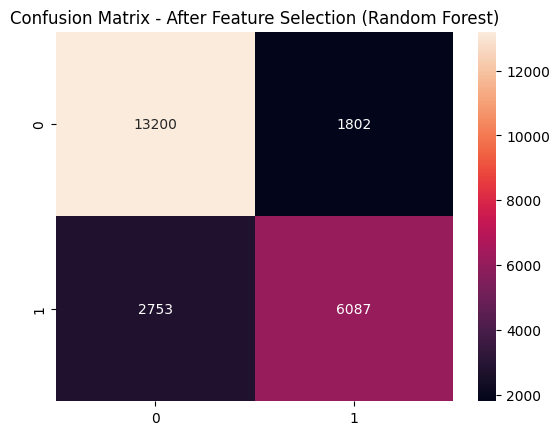

In [127]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - After Feature Selection (Random Forest)")
plt.show()

**Diagram (After Feature Selection Accuracy**

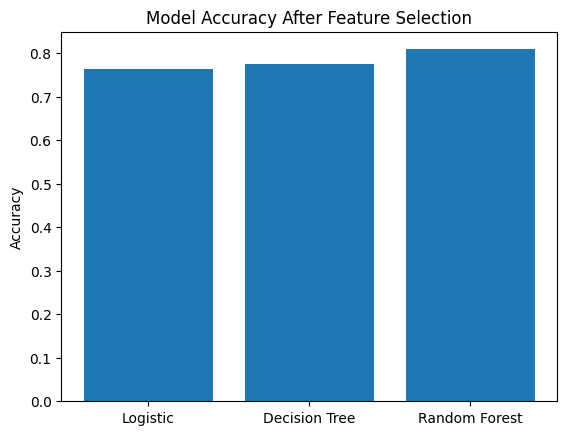

In [128]:
import matplotlib.pyplot as plt

models = ["Logistic", "Decision Tree", "Random Forest"]

accuracy = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracy)

plt.title("Model Accuracy After Feature Selection")
plt.ylabel("Accuracy")

plt.show()

Training model on FULL features...
Training model on REDUCED features...


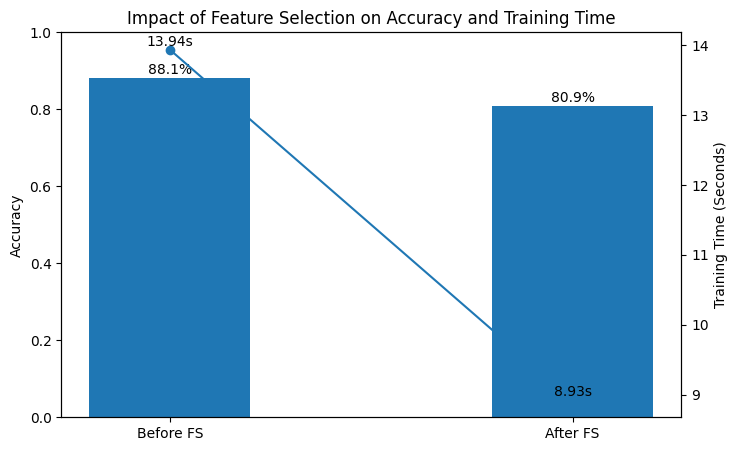

In [129]:
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# =========================
# Before Feature Selection
# =========================
print("Training model on FULL features...")

rf_full = RandomForestClassifier(
    n_estimators=100,     # Hyperparameter
    random_state=42,
    n_jobs=-1
)

start_time_full = time.time()

rf_full.fit(X_train_scaled, y_train)

time_full = time.time() - start_time_full

y_pred_full = rf_full.predict(X_test_scaled)

acc_full = accuracy_score(y_test, y_pred_full)

# =========================
# After Feature Selection
# =========================
print("Training model on REDUCED features...")

rf_red = RandomForestClassifier(
    n_estimators=100,     # Same hyperparameters
    random_state=42,
    n_jobs=-1
)

start_time_red = time.time()

rf_red.fit(X_train_selected, y_train)

time_red = time.time() - start_time_red

y_pred_red = rf_red.predict(X_test_selected)

acc_red = accuracy_score(y_test, y_pred_red)

# =========================
# Visualization
# =========================
labels = ["Before FS", "After FS"]
accuracies = [acc_full, acc_red]
times = [time_full, time_red]

fig, ax1 = plt.subplots(figsize=(8,5))

# Accuracy bars
bars = ax1.bar(labels, accuracies, width=0.4)
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1)

# Accuracy values
for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval*100:.1f}%",
        ha='center'
    )

# Training time line
ax2 = ax1.twinx()
ax2.plot(labels, times, marker='o')
ax2.set_ylabel("Training Time (Seconds)")

# Time values
for i, txt in enumerate(times):
    ax2.text(i, times[i] + 0.05, f"{txt:.2f}s", ha='center')

plt.title("Impact of Feature Selection on Accuracy and Training Time")

plt.show()